In [2]:
import sys, os
sys.path.append(os.pardir)

In [12]:
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
import numpy as np

In [21]:
from common.multi_layer_net import MultiLayerNet
from common.util import smooth_curve
from SGD import SGD
from ada_grad import AdaGrad
from momentum import Momentum
from adam import Adam

In [14]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

In [15]:
train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000

In [16]:
optimizers = {}
optimizers['SGD'] = SGD()
optimizers['Momentum'] = Momentum()
optimizers['AdaGrad'] = AdaGrad()
optimizers['Adam'] = Adam()

In [17]:
networks = {}
train_loss = {}
for key in optimizers.keys():
    networks[key] = MultiLayerNet(
        input_size=784, hidden_size_list=[100, 100, 100, 100],
        output_size=10)
    train_loss[key] = []

In [18]:
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    for key in optimizers.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizers[key].update(networks[key].params, grads)

        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)

    if i % 100 == 0:
        print( "===========" + "iteration:" + str(i) + "===========")
        for key in optimizers.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


===========iteration:0===========
SGD:2.430298916146299
Momentum:2.4647958077271896
AdaGrad:1.786056990364242
Adam:2.2520536763096555
===========iteration:100===========
SGD:1.4692342468041693
Momentum:0.3373953016273977
AdaGrad:0.11622267496092561
Adam:0.25009537215452005
===========iteration:200===========
SGD:0.7001217376632424
Momentum:0.31921634844326807
AdaGrad:0.08253726382653506
Adam:0.2433530598278146
===========iteration:300===========
SGD:0.5548240224268645
Momentum:0.20914176844850096
AdaGrad:0.0924474093538739
Adam:0.15545198823012918
===========iteration:400===========
SGD:0.380274730944713
Momentum:0.16524822443233086
AdaGrad:0.04482761666166673
Adam:0.11811615362610235
===========iteration:500===========
SGD:0.290059812390185
Momentum:0.11229202160441962
AdaGrad:0.035374712988677975
Adam:0.07116972697798633
===========iteration:600===========
SGD:0.3158618259297536
Momentum:0.1391060511538711
AdaGrad:0.10694859920258273
Adam:0.10076788184850552
===========iteration:700=

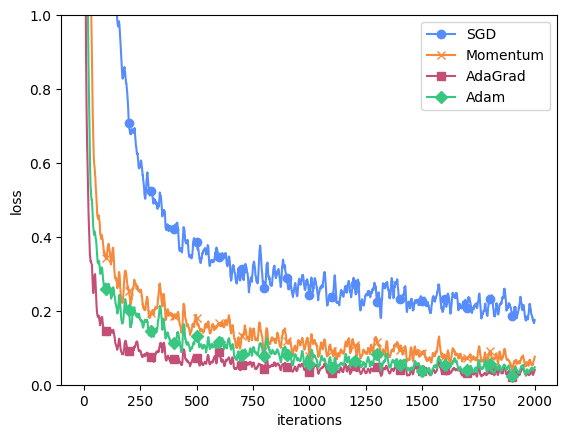

In [22]:
markers = {"SGD": "o", "Momentum": "x", "AdaGrad": "s", "Adam": "D"}
x = np.arange(max_iterations)
for key in optimizers.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 1)
plt.legend()
plt.show()